In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error,r2_score

In [21]:
#2. Load and Explore data
data= fetch_california_housing()
print(data.DESCR)
df=pd.DataFrame(data.data,columns=data.feature_names)#data (obj).data (method)
df['MedHouseVal']=data.target
df.head()

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [22]:
# 3. Preprocessing
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# 4. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
RMSE_L=np.sqrt(mean_squared_error(y_test, y_pred_lr))
R2_L=r2_score(y_test, y_pred_lr)
print("RMSE:", RMSE_L)
print("R^2 Score:", )

RMSE: 0.7455813830127764
R^2 Score:


In [29]:
# 5. Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
pr = LinearRegression()
pr.fit(X_train_poly, y_train)
y_pred_pr = pr.predict(X_test_poly)
RMSE_P = np.sqrt(mean_squared_error(y_test, y_pred_pr))
R2_P = r2_score(y_test, y_pred_pr)
print("RMSE:", RMSE_P)
print("R^2 Score:", R2_P)

RMSE: 0.6813967448044653
R^2 Score: 0.6456819729261909


In [30]:
# 6. Ridge Regression

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

RMSE_R = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

R2_R = r2_score(y_test, y_pred_ridge)

print("RMSE:", RMSE_R)

print("R^2 Score:", R2_R)

RMSE: 0.745556744281479
R^2 Score: 0.575815742891367


In [31]:
# 7. LASSO Regression

lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)
RMSE_LA=np.sqrt(mean_squared_error(y_test, y_pred_lasso))
R2_LA=r2_score(y_test, y_pred_lasso)
print("RMSE:",RMSE_LA )

print("R^2 Score:", R2_LA)

RMSE: 0.8243961598848472
R^2 Score: 0.48136113250290735


In [32]:
Metrics = pd.DataFrame(
{
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],

    "RMSE": [
        RMSE_L,
        RMSE_P,
        RMSE_R,
        RMSE_LA
    ],

    "R^2 Score": [
        R2_L,
        R2_P,
        R2_R,
        R2_LA
    ]
}
)

Metrics

,Model,RMSE,R^2 Score
0,Linear Regression,0.745581,0.575788
1,Polynomial Regression,0.681397,0.645682
2,Ridge Regression,0.745557,0.575816
3,Lasso Regression,0.824396,0.481361


In [33]:
testdf = X_test.head(1)
testdf

testdf_scaled = scaler.transform(testdf)
testdf_poly = poly.transform(testdf_scaled)

test_pr = pr.predict(testdf_poly)
testdf_lasso = lasso.predict(testdf_scaled)
testdf_lin = lr.predict(testdf_scaled)
testdf_ridge = ridge.predict(testdf_scaled)

print(test_pr)
print(testdf_lasso)
print(testdf_lin)
print(testdf_ridge)

[0.55399741]
[1.21842882]
[0.71912284]
[0.71947224]


In [35]:
med_inc = float(input("Enter the median income: "))
house_age = float(input("Enter the house age: "))
ave_rooms = float(input("Enter the average number of rooms per household: "))
ave_bedrooms = float(input("Enter the average number of bedrooms per household: "))
pop = float(input("Enter the average population of a household: "))
ave_occup = float(input("Enter the average number of households: "))
lat = float(input("Enter the latitude: "))
long = float(input("Enter the longitude: "))

indf = pd.DataFrame([[med_inc, house_age, ave_rooms, ave_bedrooms, pop, ave_occup, lat, long]] )
indf.columns = [
"MedInc","HouseAge","AveRooms","AveBedrms","Population","AveOccup","Latitude","Longitude"]
indf_scaled = scaler.transform(indf)
indf_poly = poly.transform(indf_scaled)
indf_pr = pr.predict(indf_poly)

Enter the median income:  8.0
Enter the house age:  40
Enter the average number of rooms per household:  2.2
Enter the average number of bedrooms per household:  2.4
Enter the average population of a household:  10
Enter the average number of households:  10
Enter the latitude:  10
Enter the longitude:  10


C:\Users\infos\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


['Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-setosa' 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor'
 'Iris-setosa' 'Iris-virginica']


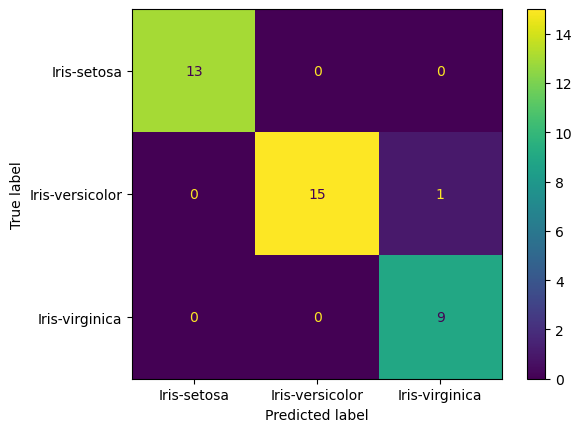

Confusion Matrix
[[13  0  0]
 [ 0 15  1]
 [ 0  0  9]]
Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       1.00      0.94      0.97        16
 Iris-virginica       0.90      1.00      0.95         9

       accuracy                           0.97        38
      macro avg       0.97      0.98      0.97        38
   weighted avg       0.98      0.97      0.97        38

Accuracy Score
0.9736842105263158


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load Dataset
dataset = pd.read_csv("Iris.csv")
# Independent and Dependent Variables
x = dataset[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
y = dataset[["Species"]]
# Split Dataset
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=0
)
# Feature Scaling
from sklearn.preprocessing import StandardScaler
st_x = StandardScaler()
x_train = st_x.fit_transform(x_train)
x_test = st_x.transform(x_test)
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=0)
log_reg.fit(x_train, y_train)
# Predicting the result
ypred = log_reg.predict(x_test)
print(ypred)
# Confusion Matrix and Accuracy Score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, ypred)
cr = classification_report(y_test, ypred)
Acc = accuracy_score(y_test, ypred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=log_reg.classes_)
disp.plot()
plt.show()

print("Confusion Matrix")
print(cm)
print("Classification Report")
print(cr)
print("Accuracy Score")
print(Acc)